In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Load & Preprocess Data

In [2]:
# Load dataset
df = pd.read_csv("../dataset/lab8/lab8-dataset.csv")
df.columns = df.columns.str.strip()  # clean any whitespace
df = df.drop(columns=["No"])         # drop the index column

print("Dataset:\n", df.head())

# Separate features and target
X = df[["Outlook", "Temperature", "Humidity", "Wind"]]
y = df["Play Tennis"]

# Encode all categorical columns using LabelEncoder
le = {}
X_encoded = X.copy()
for col in X.columns:
    le[col] = LabelEncoder()
    X_encoded[col] = le[col].fit_transform(X[col])

le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

print("\nEncoded Features:\n", X_encoded.head())
print("Encoded Labels:", y_encoded)

Dataset:
     Outlook Temperature Humidity    Wind Play Tennis
0     Sunny         Hot     High    Weak          No
1     Sunny         Hot     High  Strong          No
2  Overcast         Hot     High    Weak         Yes
3      Rain        Mild     High    Weak         Yes
4      Rain        Cool   Normal    Weak         Yes

Encoded Features:
    Outlook  Temperature  Humidity  Wind
0        2            1         0     1
1        2            1         0     0
2        0            1         0     1
3        1            2         0     1
4        1            0         1     1
Encoded Labels: [0 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 0 1 1 1 1 1
 1 1 1 0 0 1 0 1 1 1 0 1 1]


### Data Encoding

All four features and the target are categorical text values. Since most **scikit-learn** machine learning models require numerical input, we use **`LabelEncoder`** to convert each category into integer labels.

The fitted `LabelEncoder` objects are stored in the `le` dictionary so that the same mappings can be reused later when encoding custom user queries before making predictions.

### Interpretaion

The dataset contains **50 rows** and **5 columns**. Before training the model, all categorical text values are converted into numerical labels using **`LabelEncoder`**. For example, values such as **Sunny**, **Hot**, **High**, and **Weak** are mapped to integers (e.g., `Sunny → 2`, `Overcast → 0`, `Rain → 1`).

Similarly, the target variable **Play Tennis** is encoded as:
- `0` → **No**
- `1` → **Yes**

This encoded numerical representation is required because machine learning models in **scikit-learn** can only process numerical input during training and prediction.

---

## 2. Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 40, Testing samples: 10


### Train-Test Split

The dataset is divided into **80% training data** and **20% testing data**. The training set is used to train the model, while the testing set is reserved for evaluating its performance on unseen data.

Setting `random_state=42` ensures that the data is split in the same way every time the code is executed, making the results reproducible.

### Interpretation

Out of the **50 samples**, **40** are used for **training** and **10** are reserved for **testing**. The model learns only from the training data and does **not** see the test samples during training. The test set is used exclusively to evaluate how well the trained model performs on unseen data.

---

## 3(a). Train Categorical Naive Bayes

In [4]:
nb = CategoricalNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("\n===== Naive Bayes Evaluation =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb, target_names=le_y.classes_))


===== Naive Bayes Evaluation =====
Accuracy: 80.00%

Confusion Matrix:
 [[1 1]
 [1 7]]

Classification Report:
               precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10



### Model Selection

**`CategoricalNB`** is specifically designed for **categorical (label-encoded) data**. Since all the features in this dataset are categorical, it is more appropriate and efficient than **`GaussianNB`**, which is intended for continuous numerical data.

### Interpretation

**Accuracy: 80%** — The model correctly classified **8 out of 10 test samples**.

The **Confusion Matrix: `[[1, 1], [1, 7]]`** represents the following predictions:

- **1 "No" correctly predicted as No** (**True Negative**)
- **1 "No" wrongly predicted as Yes** (**False Positive**)
- **1 "Yes" wrongly predicted as No** (**False Negative**)
- **7 "Yes" correctly predicted as Yes** (**True Positive**)

For the **"No" class**:
- **Precision: 0.50**
- **Recall: 0.50**
- **F1-Score: 0.50**

The model has weaker performance in identifying **"No"** cases. Out of the **2 actual "No" samples**, it correctly classified only **1 sample**.

For the **"Yes" class**:
- **Precision: 0.88**
- **Recall: 0.88**
- **F1-Score: 0.88**

The model performs well in identifying **"Yes"** cases. Out of the **8 actual "Yes" samples**, it correctly predicted **7 samples**.

The imbalance in the test dataset (**2 "No" samples vs 8 "Yes" samples**) causes the model to favor predicting **"Yes"** more often, resulting in higher confidence and better performance for the "Yes" class compared to the "No" class.

---

## 3(b). Confusion Matrix Heatmap

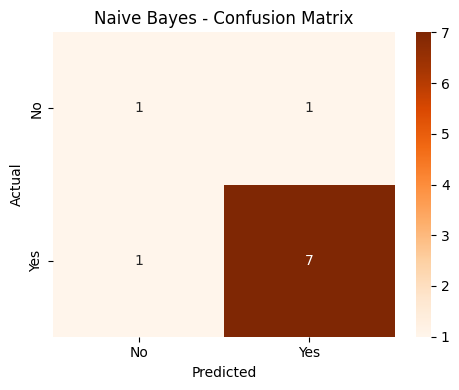

In [11]:
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_nb.png")
plt.show()

### Interpretation

The large dark cell at the **bottom-right** of the confusion matrix with a value of **7** indicates that the model performs very well at predicting **"Yes"** cases (**True Positives**).

The two **off-diagonal cells**, each with a value of **1**, represent the model's two incorrect predictions:
- One **"No"** sample was incorrectly predicted as **"Yes"** (**False Positive**).
- One **"Yes"** sample was incorrectly predicted as **"No"** (**False Negative**).

The confusion matrix shows that the model is more effective at identifying **"Yes"** cases, while the **"No"** class remains the weaker area where the model makes more errors.

---

## 4. Single Sample Inference

In [6]:
query = pd.DataFrame([{
    "Outlook": "Sunny",
    "Temperature": "Cool",
    "Humidity": "High",
    "Wind": "Strong"
}])

query_encoded = query.copy()
for col in query.columns:
    query_encoded[col] = le[col].transform(query[col])

pred_label = nb.predict(query_encoded)
pred_proba = nb.predict_proba(query_encoded)

print("\n===== Custom Query Prediction (Naive Bayes) =====")
print("Conditions: Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong")
print(f"Predicted Class: {le_y.inverse_transform(pred_label)[0]}")
print(f"Class Probabilities: No={pred_proba[0][0]:.4f}, Yes={pred_proba[0][1]:.4f}")


===== Custom Query Prediction (Naive Bayes) =====
Conditions: Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong
Predicted Class: No
Class Probabilities: No=0.9256, Yes=0.0744


### Interpretation

For the weather conditions **Sunny, Cool, High Humidity, and Strong Wind**, the **Naive Bayes model** predicts **"No"**, meaning the person is unlikely to play tennis.

The model is highly confident in this prediction:
- **P(No) = 0.9256**
- **P(Yes) = 0.0744**

Since the probability of **"No"** is much higher than **"Yes"**, the final prediction is classified as **No**.

This prediction aligns with the patterns observed in the dataset. Historically, **Sunny weather combined with High Humidity** often corresponds to a **"No"** outcome, and the presence of **Strong Wind** further increases the likelihood of not playing tennis.

---

## 5. Model Comparison

In [7]:
models = {
    "Naive Bayes":         CategoricalNB(),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM":                 SVC(probability=True, kernel='rbf')
}

print("\n===== Model Comparison =====")
print(f"{'Model':<22} {'Accuracy':>10} {'Query Pred':>12} {'P(No)':>8} {'P(Yes)':>8}")
print("-" * 65)

accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test)) * 100
    q_pred = model.predict(query_encoded)
    q_proba = model.predict_proba(query_encoded)
    label = le_y.inverse_transform(q_pred)[0]
    accuracies[name] = acc
    print(f"{name:<22} {acc:>9.2f}% {label:>12} {q_proba[0][0]:>8.4f} {q_proba[0][1]:>8.4f}")


===== Model Comparison =====
Model                    Accuracy   Query Pred    P(No)   P(Yes)
-----------------------------------------------------------------
Naive Bayes                80.00%           No   0.9256   0.0744
Decision Tree              80.00%           No   1.0000   0.0000
Logistic Regression        40.00%           No   0.9439   0.0561
SVM                        70.00%           No   0.9833   0.0167


### Interpretation

| Model | Accuracy | Query Prediction | Confidence |
|---|---|---|---|
| Naive Bayes | 80% | No | P(No) = 0.9256 — High confidence |
| Decision Tree | 80% | No | P(No) = 1.0000 — Absolute certainty (hard rule) |
| Logistic Regression | 40% | No | P(No) = 0.9439 — High confidence but lowest accuracy |
| SVM | 70% | No | P(No) = 0.9833 — Highest confidence but third-best accuracy |

All **four models agree** on the custom query prediction — the final answer is **"No"** for the given weather conditions.

The **Decision Tree** produces **P(No) = 1.0000**, indicating that the input followed a pure decision path where all training examples reaching that leaf belonged to the **"No"** class, resulting in zero ambiguity for this prediction.

**Logistic Regression** achieved only **40% accuracy**, showing poor performance on this test split. This may be because Logistic Regression assumes a linear decision boundary, which may not represent the relationships well in this small categorical dataset.

The **SVM model** achieved **70% accuracy** despite having the highest confidence score (**P(No) = 0.9833**) for the custom query. This demonstrates that high confidence for a single prediction does not always translate to better overall model performance.

Both **Naive Bayes** and **Decision Tree** achieved the highest accuracy of **80%**, making them the best-performing models for this dataset.

---

## 5(b). Accuracy Comparison Bar Chart

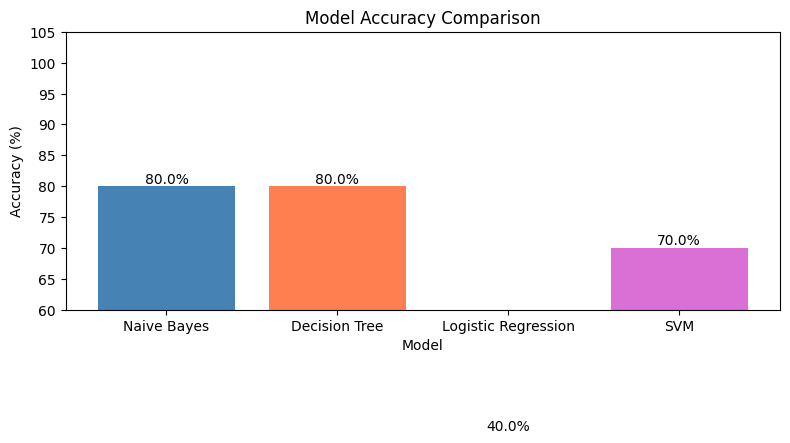

In [8]:
plt.figure(figsize=(8, 5))
bars = plt.bar(accuracies.keys(), accuracies.values(),
               color=['steelblue', 'coral', 'mediumseagreen', 'orchid'])
plt.ylim(60, 105)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
for bar, val in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

### Interpretation

The chart clearly shows that **Naive Bayes** and **Decision Tree** are the top-performing models, both achieving an accuracy of **80%**. **SVM** follows with an accuracy of **70%**, while **Logistic Regression** significantly underperforms with only **40% accuracy**.

The Logistic Regression bar is noticeably smaller compared to the other models, highlighting its poor performance on this test set.

For this small **categorical dataset (Play Tennis)**, simpler models such as **Naive Bayes** and **Decision Tree** perform better because they can naturally handle categorical relationships and decision patterns. In contrast, **Logistic Regression**, which relies on learning a linear decision boundary, is less suitable for capturing the non-linear patterns present in this dataset.

---

### Analysis Report

All four models predicted **"No"** for the custom query (**Sunny, Cool, High Humidity, Strong Wind**), but they produced different confidence levels due to their different learning mechanisms.

The **Decision Tree** was the most rigid model, assigning **P(No) = 1.0000**. This indicates that the input followed a pure decision path where the final leaf contained only **"No"** samples, resulting in complete certainty for this prediction.

**Naive Bayes** and **Logistic Regression** produced smoother probability estimates, with confidence values around **0.92–0.94 for "No"**. These models rely on statistical relationships and learned patterns rather than fixed decision rules, resulting in probability-based predictions.

Although **Logistic Regression** showed high confidence for the custom query, it achieved only **40% overall accuracy**. This highlights an important limitation: a model can be highly confident about an individual prediction while still performing poorly on unseen data. The low accuracy suggests that the linear decision boundary learned by Logistic Regression was not suitable for capturing the patterns in this small categorical dataset.

Overall, **Naive Bayes and Decision Tree** performed better because they were more suitable for handling categorical relationships and non-linear patterns present in the dataset.